In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
size_m2 = np.random.uniform(50, 250, 200)
price = 3000 * size_m2 + np.random.normal(0, 50000, 200) + 20000

df = pd.DataFrame({"size_m2": size_m2, "price": price})
df.head()

,size_m2,price
0,124.908024,360722.835229
1,240.142861,752041.268704
2,196.398788,623849.988752
3,169.731697,493477.519617
4,81.203728,356899.909823


In [2]:
X = df[["size_m2"]].values
y = df[["price"]].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# numpy array'lerini PyTorch tensörlerine çeviriyoruz
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)

torch.Size([160, 1]) torch.Size([160, 1])


In [3]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [4]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

In [5]:
epochs = 200
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()           # önceki adımdan kalan gradyanları sıfırla
    y_pred = model(X_train_t)       # ileri geçiş (forward pass)
    loss = criterion(y_pred, y_train_t)  # hatayı hesapla
    loss.backward()                 # geri yayılım (backpropagation)
    optimizer.step()                # ağırlıkları güncelle

    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 20/200, Loss: 0.1158
Epoch 40/200, Loss: 0.0871
Epoch 60/200, Loss: 0.0675
Epoch 80/200, Loss: 0.0667
Epoch 100/200, Loss: 0.0664
Epoch 120/200, Loss: 0.0663
Epoch 140/200, Loss: 0.0663
Epoch 160/200, Loss: 0.0663
Epoch 180/200, Loss: 0.0663
Epoch 200/200, Loss: 0.0663


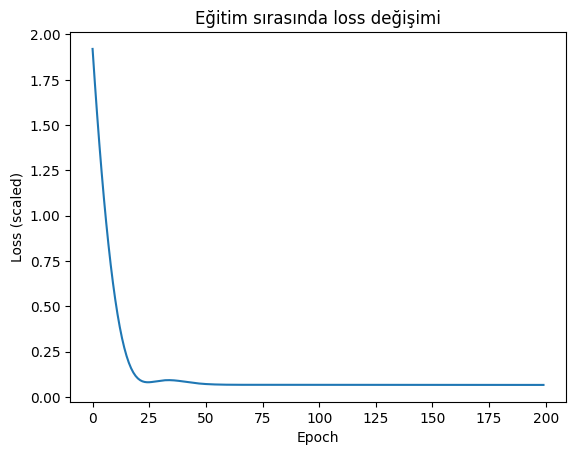

In [6]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (scaled)")
plt.title("Eğitim sırasında loss değişimi")
plt.show()

In [7]:
model.eval()
with torch.no_grad():
    y_pred_test_scaled = model(X_test_t)

y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled.numpy())
y_test_real = y_scaler.inverse_transform(y_test_t.numpy())

mse = np.mean((y_pred_test - y_test_real) ** 2)
rmse = np.sqrt(mse)
print(f"PyTorch modeli RMSE: {rmse:,.2f}")

PyTorch modeli RMSE: 52,073.57
